<a href="https://colab.research.google.com/github/fartech00/Prompt-refining/blob/main/TAFU_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

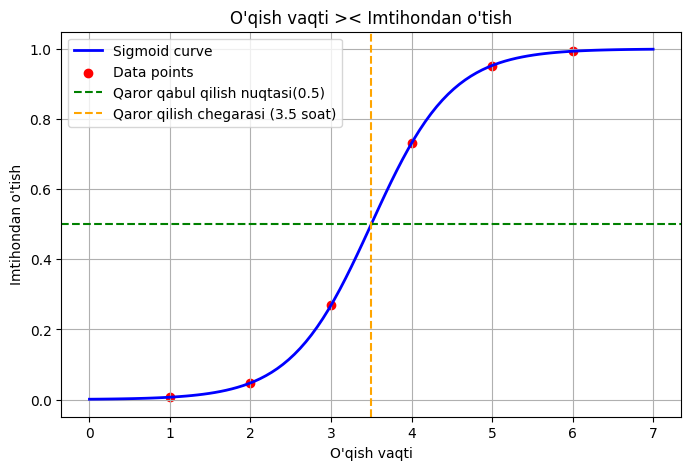

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z):
    return 1 / (1 + np.exp(-z))
w1 = 2     # weight
b = -7     # bias

hours = np.linspace(0, 7, 100)
z = w1 * hours + b
prob = sigmoid(z)

#Plot
plt.figure(figsize=(8,5))
plt.plot(hours, prob, color='blue', linewidth=2, label='Sigmoid curve')
plt.scatter([1,2,3,4,5,6], sigmoid(w1*np.array([1,2,3,4,5,6])+b),
            color='red', label='Data points')
plt.axhline(0.5, color='green', linestyle='--', label='Qaror qabul qilish nuqtasi(0.5)')
plt.axvline(3.5, color='orange', linestyle='--', label='Qaror qilish chegarasi (3.5 soat)')

plt.title("O'qish vaqti >< Imtihondan o'tish")
plt.xlabel("O'qish vaqti")
plt.ylabel("Imtihondan o'tish")
plt.legend()
plt.grid(True)
plt.show()


## **KNN:** algoritmi bo'yicha klassifikatsiyalash

In [ ]:
# ================================
# 1: Kutibxonalarni chaqirib olamiz
# ================================
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns


Malumot shakli: (1797, 64)
Belgilanganlar: (1797,)


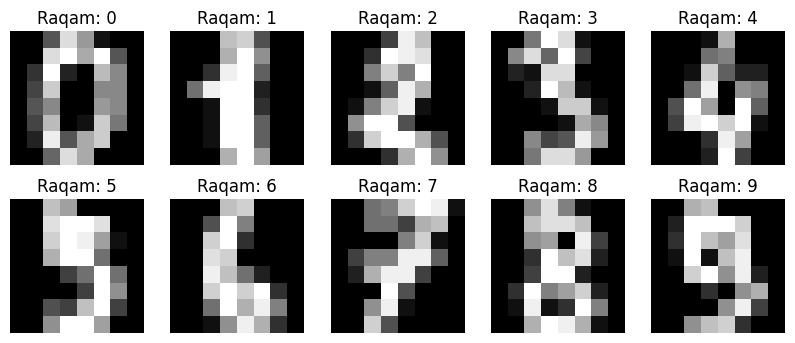

In [ ]:
# ================================
# 2: Rasmli malumotlarni yuklab olamiz
# ================================
digits = datasets.load_digits()
X = digits.data    # 8x8=64, yani har bir rasmni son ko'rinishida ibodalab olamiz
y = digits.target  # va bu sonlar qaysi raqamni DNK si ekanini bilgilab olamiz

print("Malumot shakli:", X.shape)
print("Belgilanganlar:", y.shape)

# Rasmli malumotlarni ifodalash uchun code
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Raqam: {digits.target[i]}")
    plt.axis('off')
plt.show()


In [ ]:
# ================================
# 3: Train/Test ga ajratib olamiz
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# RAqamlarni xususiyatlarini qiymatlab olamiz
# agarda biz insonni tashqi ko'rinishini klassifikatsiya qilayotgan bo'lsak:
    # Bo'yi: 150-200
    # Vazni: 50-120
    # deb belgilasak. Bunda algoritm Insonni bo'yi muhimroq, chunki qiymati kattaroq deb hisoblab qolishi mumkin.
# Shuning uchun raqamlarni xususiyatlarini qiymatlab olamiz.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)   #  k=5
knn.fit(X_train, y_train)                   # Train on training data
print("✅ K-NN Modeli o'rganishni tugatdi.")



✅ K-NN Modeli o'rganishni tugatdi.


ANIQLILIGI: 0.9703703703703703

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      1.00      0.97        55
           2       0.96      1.00      0.98        53
           3       0.98      0.98      0.98        55
           4       0.98      0.93      0.95        54
           5       0.98      0.96      0.97        55
           6       0.98      0.98      0.98        54
           7       0.93      0.98      0.95        54
           8       0.98      0.92      0.95        52
           9       0.96      0.94      0.95        54

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



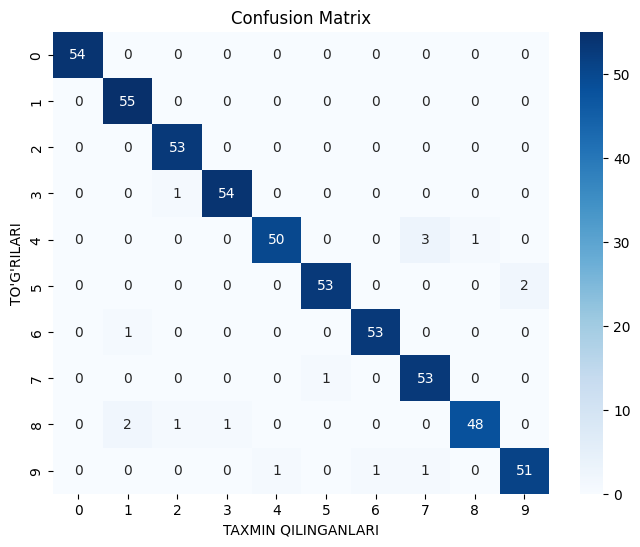

In [ ]:
# TEST QILISH
# ================================
y_pred = knn.predict(X_test)

print("ANIQLILIGI:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.xlabel("TAXMIN QILINGANLARI")
plt.ylabel("TO'G'RILARI")
plt.title("Confusion Matrix")
plt.show()


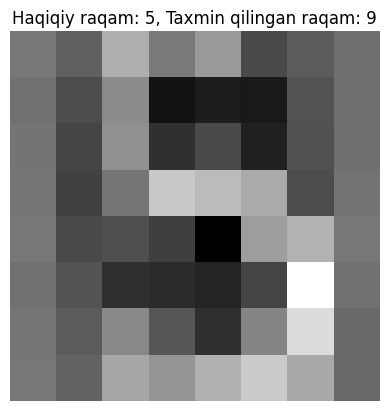

In [ ]:
# 4: K-NN da turli raqamlarni klassifikatsiya qilish testi
# ================================
import numpy as np
rand_index = np.random.randint(0, len(X_test))

# Test qilinayotgan raqamni ifodalash
plt.imshow(X_test[rand_index].reshape(8, 8), cmap='gray')
plt.title(f"Haqiqiy raqam: {y_test[rand_index]}, Taxmin qilingan raqam: {knn.predict([X_test[rand_index]])[0]}")
plt.axis('off')
plt.show()

## **Decision Tree** algoritmi bo'yicha klassifikatsiyalash


In [ ]:
# DECISION TREE algoritmi

# 1: Kutobxonalarni chaqirish
# =========================
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [ ]:
# 2: Dataset ni yuklash (raqamlar: 0-9,  8x8 pixelli)
# ===================================================
digits = load_digits()
X, y = digits.data, digits.target
# X = raqamni xususiyatlari (pixelda ifodalangan),
# y = belgilab olingan raqamlar (0-9)

print("Dataset shakli:", X.shape)   # (1797, 64) -> 1797 ta rasm, har biri 64 pixelli
print('Belgilanga sinflar, yani "y" da ifodalangan:',
      set(y))




# 3: Dataset ni training and testing qismlarga bo'lib olish
# =======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Dataset shakli: (1797, 64)
Belgilanga sinflar, yani "y" da ifodalangan: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}


In [ ]:
# 4: Decision Tree algoritmini o'qitish boshlanishi
# ==============================
dt = DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=42)
dt.fit(X_train, y_train)





DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
# 5: O'qtilgan Modelni aniqlilik darajasi
# =======================
y_pred = dt.predict(X_test)
print("Modelni aniqliligi:", accuracy_score(y_test, y_pred))

Modelni aniqliligi: 0.85


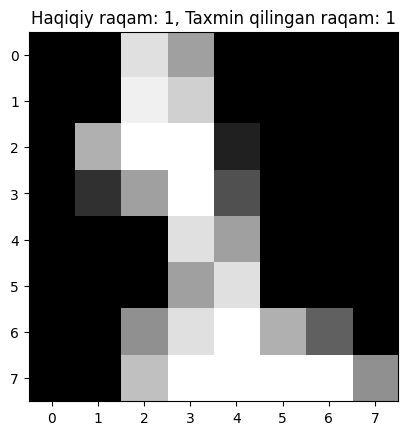

In [ ]:
# 6: Ramdom rasm bilan test qilish
# ================================

import numpy as np
i = np.random.randint(0, len(X_test))
plt.imshow(X_test[i].reshape(8, 8), cmap="gray")
plt.title(f"Haqiqiy raqam: {y_test[i]}, Taxmin qilingan raqam: {dt.predict([X_test[i]])[0]}")
plt.axis("on")
plt.show()


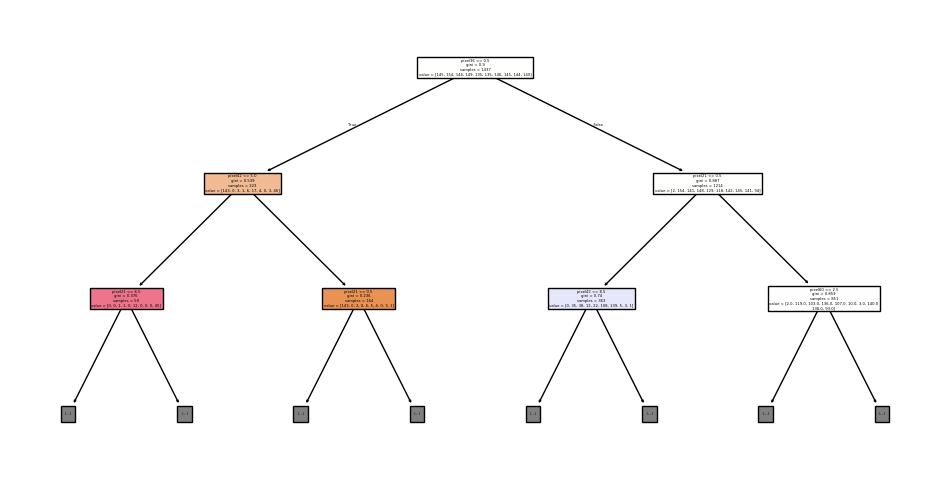

In [ ]:
plt.figure(figsize=(12, 6))
plot_tree(dt, filled=True, max_depth=2, feature_names=[f"pixel{i}" for i in range(64)])
plt.show()

## **KNN:** algoritmi bo'yicha klassifikatsiyalash

In [ ]:
# Kerakli kutubxonalarni chaqirib olamiz
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Malumotlarni yuklab olamiz
digits = datasets.load_digits()  # Raqamlar misolida
X = digits.data
y = digits.target

# Faqat 0 va 1 sonlari misolida SVM ni ishlatib ko'ramiz
X = X[(y == 0) | (y == 1)]
y = y[(y == 0) | (y == 1)]

# Malumotni taqsimlash
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normallashtirish
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# SVM algoritmi yordamida model qurishni boshlash

model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)

SVC()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56  0]
 [ 0 52]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        56
           1       1.00      1.00      1.00        52

    accuracy                           1.00       108
   macro avg       1.00      1.00      1.00       108
weighted avg       1.00      1.00      1.00       108



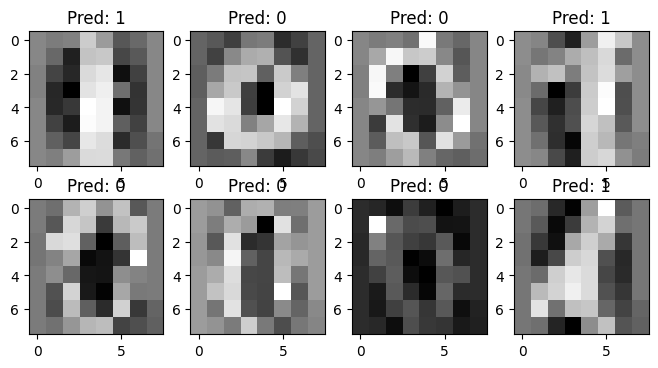

In [ ]:
plt.figure(figsize=(8,4))
for index, (image, label) in enumerate(zip(X_test[0:8], y_pred[0:8])):
    plt.subplot(2, 4, index + 1)
    plt.imshow(image.reshape(8,8), cmap=plt.cm.gray)
    plt.title(f'Pred: {label}')
plt.show()

## **Logistic regression:** algoritmi bo'yicha klassifikatsiyalash